In [1]:
import gym
import numpy as np
from PIL import Image
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Actor 網路：輸入 state，輸出 mean, std
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256,
                 log_std_min=-20, log_std_max=2):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # latent_dim = hidden_dim，因此輸出 action_dim*2
        self.mean_log_std = nn.Linear(hidden_dim, action_dim * 2)
        self.log_std_min = log_std_min
        self.log_std_max = log_std_max

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        mean_log_std = self.mean_log_std(x)
        mean, log_std = torch.chunk(mean_log_std, 2, dim=-1)
        log_std = torch.clamp(log_std, self.log_std_min, self.log_std_max)
        std = torch.exp(log_std)
        return mean, std

    def sample(self, state):
        mean, std = self.forward(state)
        dist = Normal(mean, std)
        # reparameterization trick
        action = dist.rsample()
        log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
        return action, log_prob

# Critic 網路：輸入 state 與 action concat，輸出 Q-value
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.q_out = nn.Linear(hidden_dim, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q_value = self.q_out(x)
        return q_value

# 簡易 Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=1e6):
        self.buffer = deque(maxlen=int(capacity))

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, done = map(np.stack, zip(*batch))
        return (
            torch.FloatTensor(s).to(device),
            torch.FloatTensor(a).to(device),
            torch.FloatTensor(r).unsqueeze(1).to(device),
            torch.FloatTensor(s_next).to(device),
            torch.FloatTensor(done).unsqueeze(1).to(device),
        )

    def __len__(self):
        return len(self.buffer)

# SAC Agent 包裝
class SACAgent:
    def __init__(self,
                 state_dim, action_dim,
                 hidden_dim=256,
                 gamma=0.99, tau=0.005,
                 alpha=0.2, lr=3e-4,
                 buffer_size=1e6,
                 batch_size=256):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.tau = tau
        self.alpha = alpha
        self.batch_size = batch_size

        # networks
        self.actor = Actor(state_dim, action_dim, hidden_dim).to(device)
        self.critic1 = Critic(state_dim, action_dim, hidden_dim).to(device)
        self.critic2 = Critic(state_dim, action_dim, hidden_dim).to(device)
        # target networks
        self.target_critic1 = Critic(state_dim, action_dim, hidden_dim).to(device)
        self.target_critic2 = Critic(state_dim, action_dim, hidden_dim).to(device)
        self.target_critic1.load_state_dict(self.critic1.state_dict())
        self.target_critic2.load_state_dict(self.critic2.state_dict())

        # optimizers
        self.actor_optimizer   = optim.Adam(self.actor.parameters(),   lr=lr)
        self.critic1_optimizer = optim.Adam(self.critic1.parameters(), lr=lr)
        self.critic2_optimizer = optim.Adam(self.critic2.parameters(), lr=lr)

        self.replay_buffer = ReplayBuffer(buffer_size)

    # 給定 state，回傳一個連續動作
    def take_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        action, _ = self.actor.sample(state)
        return action.detach().cpu().numpy()[0]

    # 單步更新 Q-networks 與 Actor-network
    def update(self):
        if len(self.replay_buffer) < self.batch_size:
            return

        s, a, r, s_next, done = self.replay_buffer.sample(self.batch_size)

        # —— Critic 更新 —— #
        with torch.no_grad():
            a_next, logp_next = self.actor.sample(s_next)
            q1_next = self.target_critic1(s_next, a_next)
            q2_next = self.target_critic2(s_next, a_next)
            q_next = torch.min(q1_next, q2_next) - self.alpha * logp_next
            q_target = r + (1 - done) * self.gamma * q_next

        q1 = self.critic1(s, a)
        q2 = self.critic2(s, a)
        loss_q1 = F.mse_loss(q1, q_target)
        loss_q2 = F.mse_loss(q2, q_target)

        self.critic1_optimizer.zero_grad()
        loss_q1.backward()
        self.critic1_optimizer.step()

        self.critic2_optimizer.zero_grad()
        loss_q2.backward()
        self.critic2_optimizer.step()

        # —— Actor 更新 —— #
        a_new, logp_new = self.actor.sample(s)
        q1_new = self.critic1(s, a_new)
        q2_new = self.critic2(s, a_new)
        actor_loss = (self.alpha * logp_new - torch.min(q1_new, q2_new)).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # —— Target networks 軟更新 —— #
        for t, p in zip(self.target_critic1.parameters(), self.critic1.parameters()):
            t.data.copy_(self.tau * p.data + (1 - self.tau) * t.data)
        for t, p in zip(self.target_critic2.parameters(), self.critic2.parameters()):
            t.data.copy_(self.tau * p.data + (1 - self.tau) * t.data)

    # 訓練主流程：呼叫 env.step / env.reset，並即時繪製 reward–episode 曲線
    def fit(self, env, num_episodes=1000, max_steps=1000):
        rewards = []
        for ep in range(num_episodes):
            state = env.reset()
            ep_reward = 0
            for t in range(max_steps):
                action = self.take_action(state)
                next_state, reward, done, _ = env.step(action)
                self.replay_buffer.push(state, action, reward, next_state, done)
                state = next_state
                ep_reward += reward

                self.update()
                if done:
                    break

            rewards.append(ep_reward)
            clear_output(wait=True)
            plt.figure(figsize=(8,4))
            plt.plot(rewards)
            plt.xlabel('Episode')
            plt.ylabel('Reward')
            plt.title('SAC Training Progress')
            plt.show()

        return rewards

# ===== 使用範例 =====
# from your_env import YourEnv
# env = YourEnv()
# agent = SACAgent(state_dim=env.observation_space.shape[0],
#                  action_dim=env.action_space.shape[0])
# rewards = agent.fit(env, num_episodes=500) 


In [3]:
class Env:
    def __init__(self):
        self.env = gym.make("MountainCarContinuous-v0", render_mode='rgb_array')
        self.state = self.env.reset()[0]
        self.done = False
    def step(self, action):
        self.state, reward, terminated, truncated, info = self.env.step(action)
        self.done = terminated or truncated
        return self.state, reward, self.done, info
    def reset(self):
        self.state = self.env.reset()[0]
        self.done = False
        return self.state
    def render(self):
        return self.env.render()
    def close(self):
        self.env.close()

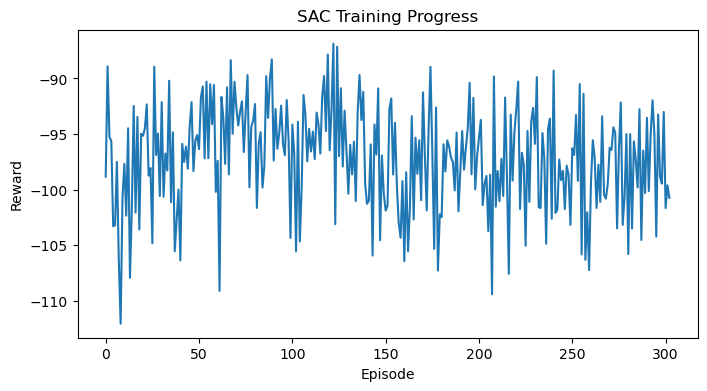

KeyboardInterrupt: 

In [4]:
agent = SACAgent(state_dim=2, action_dim=1)
agent.fit(Env(), num_episodes=2000)

In [ ]:
import numpy as np

class FSM_env:
    """
    基於有限狀態機的環境包裝器，實現Reward Machine概念
    支援potential-based reward shaping以保持policy invariance
    """
    def __init__(self, base_env, gamma=0.99):
        """
        初始化FSM環境
        
        參數:
            base_env: 基礎環境，需要有step和reset方法
            gamma: 折扣因子，用於reward shaping
        """
        self.env = base_env
        self.gamma = gamma
        self.current_state = None
        self.current_fsm_state = None
        self.reset()
        
        # 初始化potential函數字典 (用於reward shaping)
        self.potential_dict = self._initialize_potential()
        
    def reset(self):
        """重置環境並返回初始狀態"""
        self.current_state = self.env.reset()
        self.current_fsm_state = self._get_initial_fsm_state()
        return self.current_state
    
    def step(self, action):
        """
        執行動作並返回下一個狀態、獎勵和是否結束
        
        同時處理FSM狀態轉換和reward shaping
        """
        # 在基礎環境中執行動作
        next_state, base_reward, done, info = self.env.step(action)
        
        # 儲存目前FSM狀態用於potential計算
        old_fsm_state = self.current_fsm_state
        
        # 檢查FSM狀態是否需要轉換
        self.current_fsm_state = self._check_status(self.current_state, action, next_state)
        
        # 根據FSM狀態計算獎勵
        reward = self._get_reward(self.current_fsm_state, self.current_state, action, next_state)
        
        # 應用potential-based reward shaping
        shaped_reward = self._apply_reward_shaping(old_fsm_state, self.current_fsm_state, reward)
        
        # 更新當前狀態
        self.current_state = next_state
        
        return next_state, shaped_reward, done, info
    
    def _get_initial_fsm_state(self):
        """
        獲取FSM的初始狀態
        根據任務需求自定義初始狀態
        """
        return 0
    
    def _check_status(self, state, action, next_state):
        """
        檢查是否需要進行FSM狀態轉換
        
        參數:
            state: 當前環境狀態
            action: 執行的動作
            next_state: 執行動作後的環境狀態
            
        返回:
            下一個FSM狀態
        """
        # 這是需要您實現的部分，根據您的任務定義狀態轉換邏輯
        # 範例:
        current_fsm_state = self.current_fsm_state
        
        # 範例邏輯 - 檢測事件並轉換狀態
        # 例如，如果agent拿到咖啡，從狀態0轉到狀態1
        if self._detect_event(state, action, next_state, "get_coffee"):
            if current_fsm_state == 0:
                return 1
                
        # 例如，如果agent到達辦公室並持有咖啡，從狀態1轉到狀態2
        if self._detect_event(state, action, next_state, "reach_office") and current_fsm_state == 1:
            return 2
            
        # 若沒有轉換，保持原狀態
        return current_fsm_state
    
    def _detect_event(self, state, action, next_state, event_name):
        """
        檢測特定事件是否發生
        這個函數需要根據您的環境和任務定義來實現
        """
        if event_name == "get_coffee":
            pass
        elif event_name == "reach_office":
            pass
        
        return False  # 預設返回False
    
    def _get_reward(self, fsm_state, state, action, next_state):
        """
        基於當前FSM狀態計算獎勵
        
        參數:
            fsm_state: 當前FSM狀態
            state: 當前環境狀態
            action: 執行的動作
            next_state: 執行動作後的環境狀態
            
        返回:
            獎勵值
        """
        # 這是需要您實現的部分，定義不同FSM狀態下的獎勵函數
        # 範例:
        if fsm_state == 0:
            # 初始狀態，尋找咖啡的獎勵
            reward = 0
        elif fsm_state == 1:
            # 拿到咖啡後，尋找辦公室的獎勵
            reward = 0.1
        elif fsm_state == 2:
            # 任務完成，給予高獎勵
            reward = 1.0
        else:
            reward = 0
            
        return reward
    
    def _initialize_potential(self):
        """
        初始化每個FSM狀態的potential值
        
        用於實現potential-based reward shaping
        """
        # 範例 potential 值，應根據任務設計適當的值
        # 通常，越接近目標狀態的potential越高
        potential_dict = {
            0: 0,      # 初始狀態
            1: 0.5,    # 拿到咖啡
            2: 1.0,    # 完成任務
        }
        return potential_dict
    
    def _apply_reward_shaping(self, old_fsm_state, new_fsm_state, original_reward):
        """
        應用potential-based reward shaping
        
        公式: r' = r + γ * Φ(s') - Φ(s)
        
        參數:
            old_fsm_state: 原FSM狀態
            new_fsm_state: 新FSM狀態
            original_reward: 原始獎勵
            
        返回:
            經過shaping後的獎勵
        """
        old_potential = self.potential_dict.get(old_fsm_state, 0)
        new_potential = self.potential_dict.get(new_fsm_state, 0)
        
        # 根據論文中的potential-based shaping公式
        shaping_reward = self.gamma * new_potential - old_potential
        shaped_reward = original_reward + shaping_reward
        
        return shaped_reward
